<a href="https://colab.research.google.com/github/elviraasch/Analisis-dan-Visualisasi-Data/blob/main/Tugas_4_AVD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **A - Preprocessing Data**

In [71]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

print("--- Data Preprocessing ---")

# Load the data
df = pd.read_csv('marketing_campaign.csv', sep='\t')

# Display head and info
print(df.head())
print(df.info())

df = df.drop_duplicates()

print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

target_column = 'Response'

kolom_konstan = [col for col in df.columns if df[col].nunique() <= 1]
# Ensure the target column is not dropped if it happens to be constant
if target_column in kolom_konstan:
    kolom_konstan.remove(target_column)

df = df.drop(columns=kolom_konstan)

kolom_numerik_awal = df.select_dtypes(include=['int64', 'float64']).columns
# Exclude target_column from outlier removal as it's a binary variable
kolom_numerik_untuk_outlier = [col for col in kolom_numerik_awal if col != target_column]

# Change: Cap outliers instead of removing rows
for col in kolom_numerik_untuk_outlier:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR
    # Cap values outside the bounds
    df[col] = np.where(df[col] < batas_bawah, batas_bawah, df[col])
    df[col] = np.where(df[col] > batas_atas, batas_atas, df[col])

fitur_numerik = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
fitur_kategorikal = df.select_dtypes(include=['object', 'category']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Define target variable (y) and features (X)
X = df.drop(columns=['ID', target_column], errors='ignore')
y = df[target_column]

# Update feature lists based on the new X dataframe for preprocessing
fitur_numerik_X = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
fitur_kategorikal_X = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Define categorical transformer
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, fitur_numerik_X),
        ('cat', categorical_transformer, fitur_kategorikal_X)
    ],
    remainder='passthrough'
)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_clean = preprocessor.fit_transform(X_train)
X_test_clean = preprocessor.transform(X_test)


--- Data Preprocessing ---
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  

# **B - Dimension Reduction**

In [72]:
from sklearn.feature_selection import SelectKBest, f_classif
df_clean = df.select_dtypes(include=['int64', 'float64']).fillna(df.median(numeric_only=True))

X = df_clean.drop(columns=['Response', 'ID'], errors='ignore')
y = df_clean['Response']

# Remove columns from X that have zero variance to prevent RuntimeWarning
zero_variance_cols = X.columns[X.var() == 0]
if not zero_variance_cols.empty:
    print(f"Removing zero variance columns from X: {list(zero_variance_cols)}")
    X = X.drop(columns=zero_variance_cols)

selector = SelectKBest(score_func=f_classif, k=5)
X_selected = selector.fit_transform(X, y)

# Mendapatkan nama-nama kolom terbaik yang terpilih
kolom_terpilih = X.columns[selector.get_support()]

# Mengonversi hasil menjadi DataFrame
df_selected = pd.DataFrame(X_selected, columns=kolom_terpilih)

print(f"Ukuran data sebelum seleksi: {X.shape}")
print(f"Ukuran data setelah seleksi: {df_selected.shape}")
print(f"5 Fitur terbaik yang otomatis terpilih: {list(kolom_terpilih)}")

constant_cols = [col for col in df.columns if df[col].nunique() <= 1]

# Ensure 'Response' is not dropped, as it's the target variable
if 'Response' in constant_cols:
    constant_cols.remove('Response')

cols_to_drop = constant_cols

df_new = df.drop(columns=cols_to_drop, errors='ignore')
df_new.to_csv('marketing_campaign_preprocessed.csv', index=False)

print(f"Ukuran dataset baru: {df_new.shape[0]} baris dan {df_new.shape[1]} kolom.")

Removing zero variance columns from X: ['AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain']
Ukuran data sebelum seleksi: (2240, 16)
Ukuran data setelah seleksi: (2240, 5)
5 Fitur terbaik yang otomatis terpilih: ['Income', 'Recency', 'MntWines', 'MntMeatProducts', 'NumCatalogPurchases']
Ukuran dataset baru: 2240 baris dan 21 kolom.


# **C - MOdel Clustering**

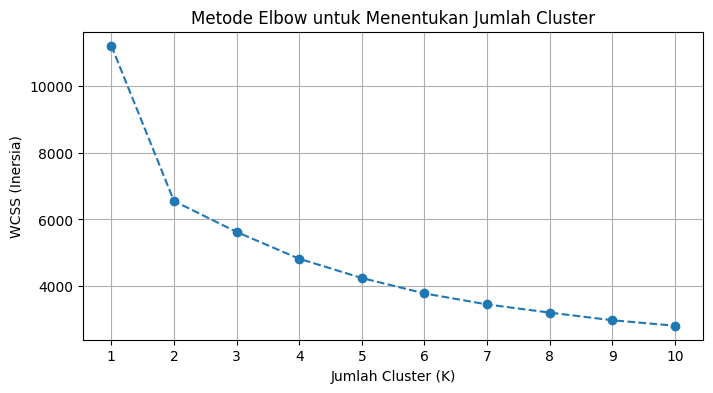

--- RATA-RATA FITUR PER CLUSTER ---
               Income        Age  Total_Spending  Total_Purchases  \
Cluster                                                             
0        70093.867632  47.502976     1084.945437        21.429563   
1        40533.834361  45.744681      135.288754         8.848024   
2        32656.284452  40.327526      157.034843         9.554007   

         Enrollment_Days  
Cluster                   
0             567.550595  
1             359.071429  
2             697.393728  


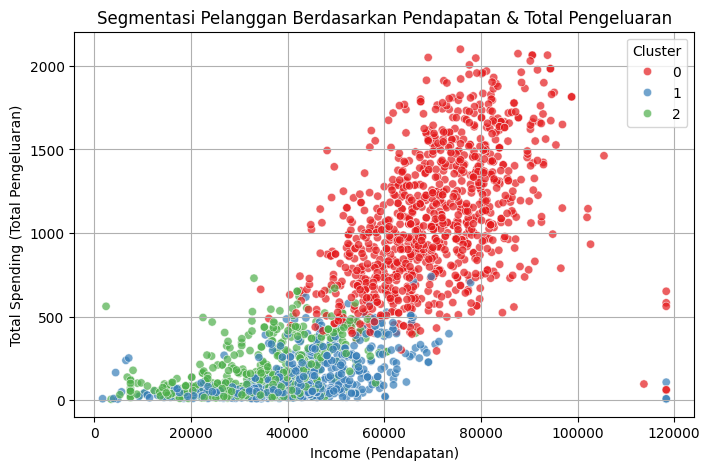

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

df = pd.read_csv('marketing_campaign_preprocessed.csv')

# Calculate Age
df['Age'] = 2014 - df['Year_Birth']

# Calculate Total_Spending
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['Total_Spending'] = df[spending_cols].sum(axis=1)

# Calculate Total_Purchases
purchases_cols = ['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
df['Total_Purchases'] = df[purchases_cols].sum(axis=1)

# Calculate Enrollment_Days
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')
# Assuming a reference date for enrollment calculation, e.g., '2015-01-01'
reference_date = pd.to_datetime('2015-01-01')
df['Enrollment_Days'] = (reference_date - df['Dt_Customer']).dt.days

fitur_cluster = ['Income', 'Age', 'Total_Spending', 'Total_Purchases', 'Enrollment_Days']
X = df[fitur_cluster]

# Impute missing values in X before scaling
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

wcss = []

# uji performa dari 1 sampai 10 cluster
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Visualisasi Grafik Elbow
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Metode Elbow untuk Menentukan Jumlah Cluster')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS (Inersia)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

k_optimal = 3
model_kmeans = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42, n_init=10)

# Fit model dan prediksi cluster untuk setiap baris data
df['Cluster'] = model_kmeans.fit_predict(X_scaled)

# Melihat rata-rata setiap variabel berdasarkan kelompok clusternya
df_profiling = df.groupby('Cluster')[fitur_cluster].mean()

print("--- RATA-RATA FITUR PER CLUSTER ---")
print(df_profiling)
# Plot interaksi antara Income dan Total Spending berdasarkan Cluster-nya
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Income', y='Total_Spending', hue='Cluster', palette='Set1', alpha=0.7)
plt.title('Segmentasi Pelanggan Berdasarkan Pendapatan & Total Pengeluaran')
plt.xlabel('Income (Pendapatan)')
plt.ylabel('Total Spending (Total Pengeluaran)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# Simpan hasil akhir yang sudah memiliki label cluster
df.to_csv('marketing_campaign_clustered.csv', index=False)

# **D - Evaluasi Model**

--- KINERJA MODEL KLASIFIKASI ---
Akurasi Model: 84.60%

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91       381
           1       0.47      0.27      0.34        67

    accuracy                           0.85       448
   macro avg       0.68      0.61      0.63       448
weighted avg       0.82      0.85      0.83       448

ROC-AUC Score: 0.7454


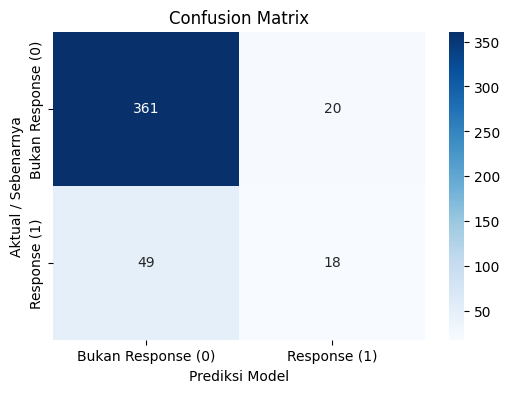

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

df = pd.read_csv('marketing_campaign.csv', sep='\t')

# Mengisi nilai kosong (NaN) pada kolom Income menggunakan nilai Median
df['Income'] = df['Income'].fillna(df['Income'].median())

# Menyaring outliers (Tahun kelahiran ekstrem & pendapatan tidak realistis)
df = df[df['Year_Birth'] >= 1940]
df = df[df['Income'] < 600000]

# Menghitung Usia (Age)
df['Age'] = 2014 - df['Year_Birth']

# Otomatis mengambil dan menjumlahkan semua kolom pengeluaran yang berawalan 'Mnt'
spending_cols = [col for col in df.columns if col.startswith('Mnt')]
df['Total_Spending'] = df[spending_cols].sum(axis=1)

# Otomatis mengambil dan menjumlahkan semua kolom transaksi yang mengandung kata 'Purchases'
purchase_cols = [col for col in df.columns if 'Purchases' in col]
df['Total_Purchases'] = df[purchase_cols].sum(axis=1)

# Menghitung Jumlah Hari Bergabung (Enrollment Days)
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')
max_date = df['Dt_Customer'].max()
df['Enrollment_Days'] = (max_date - df['Dt_Customer']).dt.days

X = df[['Income', 'Age', 'Total_Spending', 'Total_Purchases', 'Enrollment_Days']]
y = df['Response']

# Menggunakan stratify=y agar pembagian kelas 0 dan 1 seimbang antara Train & Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("--- KINERJA MODEL KLASIFIKASI ---")
# Akurasi keseluruhan
Akurasi = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {Akurasi*100:.2f}%\n")

# Classification Report (Precision, Recall, F1-Score per Kelas)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Pengecekan Aman untuk ROC-AUC agar tidak memicu IndexError
if model.classes_.shape[0] > 1:
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    print(f"ROC-AUC Score: {roc_auc:.4f}")
else:
    print("ROC-AUC Score tidak dapat dihitung karena model hanya mengenali 1 kelas di data training.")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bukan Response (0)', 'Response (1)'],
            yticklabels=['Bukan Response (0)', 'Response (1)'])
plt.title('Confusion Matrix')
plt.ylabel('Aktual / Sebenarnya')
plt.xlabel('Prediksi Model')
plt.show()

# **E - Customer Segmentation**

--- KARAKTERISTIK (RATA-RATA) SETIAP SEGMEN PELANGGAN ---
               Income        Age  Total_Spending  Total_Purchases  \
Cluster                                                             
0        46094.482759  54.908046      237.208812        11.522989   
1        70694.430136  46.530761     1193.192909        21.869656   
2        32197.041722  36.507285      115.087417         8.300662   

         Enrollment_Days  
Cluster                   
0             280.264368  
1             390.494265  
2             357.953642  

--- DISTRIBUSI JUMLAH PELANGGAN PER CLUSTER ---
Cluster
1    959
2    755
0    522
Name: count, dtype: int64


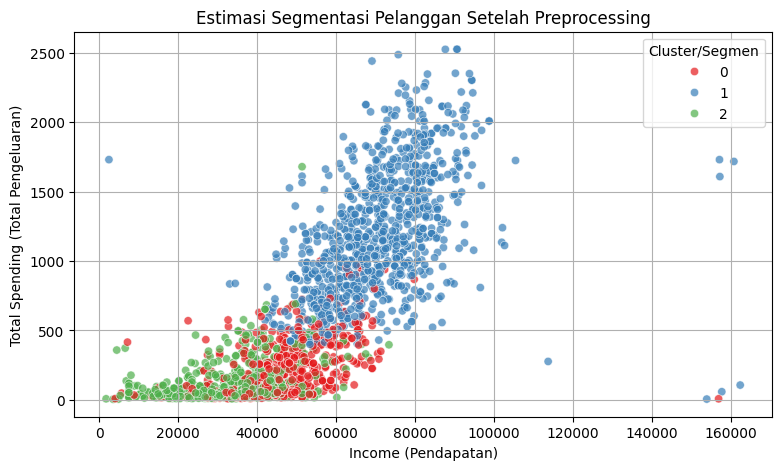


Selesai! Hasil segmentasi disimpan ke file 'marketing_campaign_segmented.csv'.


In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('marketing_campaign.csv', sep='\t')

# Imputasi missing values pada kolom Income menggunakan nilai Median
income_median = df['Income'].median()
df['Income'] = df['Income'].fillna(income_median)

# Menyaring Outliers (Tahun kelahiran tidak realistis & pendapatan ekstrem)
df = df[df['Year_Birth'] >= 1940]
df = df[df['Income'] < 600000]


# Transformasi Year_Birth menjadi Usia (Age) dengan tahun referensi data (2014)
df['Age'] = 2014 - df['Year_Birth']

# Otomatis menjumlahkan semua kolom pengeluaran yang berawalan 'Mnt'
spending_cols = [col for col in df.columns if col.startswith('Mnt')]
df['Total_Spending'] = df[spending_cols].sum(axis=1)

# Otomatis menjumlahkan semua kolom transaksi yang mengandung kata 'Purchases'
purchase_cols = [col for col in df.columns if 'Purchases' in col]
df['Total_Purchases'] = df[purchase_cols].sum(axis=1)

# Transformasi tipe data string ke DateTime dan hitung jumlah hari bergabung (Enrollment_Days)
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')
max_date = df['Dt_Customer'].max()
df['Enrollment_Days'] = (max_date - df['Dt_Customer']).dt.days

# Memilih fitur numerik hasil preprocessing utama untuk segmentasi pelanggan
fitur_segmentasi = ['Income', 'Age', 'Total_Spending', 'Total_Purchases', 'Enrollment_Days']
X = df[fitur_segmentasi]

# Karena K-Means berbasis jarak, skala seluruh fitur wajib disamakan (Standardisasi)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Berdasarkan metode elbow, umumnya titik siku yang ideal melandai di angka K=3
k_optimal = 3
model_kmeans = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42)

# Melakukan prediksi kelompok cluster dan memasukannya ke kolom baru
df['Cluster'] = model_kmeans.fit_predict(X_scaled)

# Melihat nilai rata-rata tiap fitur berdasarkan kelompok clusternya
df_profiling = df.groupby('Cluster')[fitur_segmentasi].mean()
print("--- KARAKTERISTIK (RATA-RATA) SETIAP SEGMEN PELANGGAN ---")
print(df_profiling)

print("\n--- DISTRIBUSI JUMLAH PELANGGAN PER CLUSTER ---")
print(df['Cluster'].value_counts())

# Plot interaksi sebaran cluster antara Income vs Total Spending
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='Income', y='Total_Spending', hue='Cluster', palette='Set1', alpha=0.7)
plt.title('Estimasi Segmentasi Pelanggan Setelah Preprocessing')
plt.xlabel('Income (Pendapatan)')
plt.ylabel('Total Spending (Total Pengeluaran)')
plt.legend(title='Cluster/Segmen')
plt.grid(True)
plt.show()

# Menyimpan dataset akhir yang sudah bersih sekaligus memiliki label kelompok 'Cluster'
df.to_csv('marketing_campaign_segmented.csv', index=False)
print("\nSelesai! Hasil segmentasi disimpan ke file 'marketing_campaign_segmented.csv'.")